Roll Number: **102303560**\
`a` (last digit) = **0**\
`b` (second last digit) = **6**\
`c` (third last digit) = **5**

## PART A: Deep Network Structural Stress Test 

In [1]:
import numpy as np
import pandas as pd

a = 0   # last digit
b = 6   # second last digit
c = 5   # third last digit

hidden_layer_width = 6 + a
n_hidden = 4 + (b % 3) 
lr = 0.002 * (c + 1)
activation = 'relu'
w_range= [-1 / (a + 1) , 1 / (a + 1)]
bias = 0
epochs = 400

print(f"Hidden layer width: {hidden_layer_width}")
print(f"Number of hidden layers: {n_hidden}")
print(f"Learning rate: {lr}")
print(f"Activation: {activation}")
print(f"Weight initialization range: {w_range}")
print(f"Bias: {bias}")
print(f"Epochs: {epochs}")

Hidden layer width: 6
Number of hidden layers: 4
Learning rate: 0.012
Activation: relu
Weight initialization range: [-1.0, 1.0]
Bias: 0
Epochs: 400


In [2]:
np.random.seed(42)
n = 200
x_data = np.linspace(-np.pi, np.pi, n).reshape(-1, 1)
y_data = np.sin(x_data)

x_data = (x_data - x_data.mean()) / (x_data.std() + 1e-8)
y_data = (y_data - y_data.mean()) / (y_data.std() + 1e-8)

print(f"X shape: {x_data.shape}, Y shape: {y_data.shape}")

X shape: (200, 1), Y shape: (200, 1)


In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def apply_activation(z, activation):
    if activation == 'relu':
        return relu(z)
    return sigmoid(z)

def apply_activation_derivative(z, activation):
    if activation == 'relu':
        return relu_derivative(z)
    return sigmoid_derivative(z)

def init_weights(input_dim, hidden_width, num_hidden, output_dim, w_range, bias=0.0):
    sizes = [input_dim] + [hidden_width] * num_hidden + [output_dim]
    W = []
    b_list = []
    for i in range(len(sizes) - 1):
        if isinstance(w_range, list):
            W.append(np.random.uniform(w_range[0], w_range[1], (sizes[i], sizes[i + 1])))
        else:
            W.append(np.random.uniform(-w_range, w_range, (sizes[i], sizes[i + 1])))
        b_list.append(np.full((1, sizes[i + 1]), bias))
    return W, b_list

def forward_pass(X, W, b_list, activation):
    A = [X]
    Z = []
    for i in range(len(W) - 1): 
        z = A[-1] @ W[i] + b_list[i]
        Z.append(z)
        A.append(apply_activation(z, activation))
    z_out = A[-1] @ W[-1] + b_list[-1]
    Z.append(z_out)
    A.append(z_out)
    return A, Z

def compute_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def backward_pass(y_true, A, Z, W, activation):
    m = y_true.shape[0]
    dW = [None] * len(W)
    db = [None] * len(W)
    delta = (2.0 / m) * (A[-1] - y_true)
    for i in reversed(range(len(W))):
        dW[i] = A[i].T @ delta
        db[i] = np.sum(delta, axis=0, keepdims=True)
        if i > 0:
            delta = (delta @ W[i].T) * apply_activation_derivative(Z[i - 1], activation)
    return dW, db

def update_params(W, b_list, dW, db, lr):
    for i in range(len(W)):
        W[i]      = W[i] - lr * dW[i]
        b_list[i] = b_list[i] - lr * db[i]
    return W, b_list

def compute_gradient_norm_first(dW):
    return np.linalg.norm(dW[0])

def compute_gradient_norm_last(dW):
    return np.linalg.norm(dW[-2])

def compute_gri(dW):
    gn_first = compute_gradient_norm_first(dW)
    gn_last  = compute_gradient_norm_last(dW)
    return gn_first / (gn_last + 1e-12)

def train_network(X, y, W, b_list, lr, activation, epochs=400, verbose=True):
    history = {'loss': [], 'gn_first': [], 'gn_last': []}
    for ep in range(1, epochs + 1):
        A, Z = forward_pass(X, W, b_list, activation)
        loss = compute_loss(A[-1], y)
        dW, db = backward_pass(y, A, Z, W, activation)
        gn_first = compute_gradient_norm_first(dW)
        gn_last  = compute_gradient_norm_last(dW)
        W, b_list = update_params(W, b_list, dW, db, lr)
        history['loss'].append(loss)
        history['gn_first'].append(gn_first)
        history['gn_last'].append(gn_last)
        if verbose and ep in (1, 100, 400):
            print(f"Epoch {ep:>4}: Loss = {loss:.6f} | "
                  f"||grad_W_first|| = {gn_first:.6f} | "
                  f"||grad_W_last||  = {gn_last:.6f}")
    return W, b_list, history

In [4]:
#Run 1 (lr = 0.012, relu, w∈[-1,1], bias=0)
np.random.seed(0)

w1, b1 = init_weights(
    input_dim    = 1,
    hidden_width = hidden_layer_width,
    num_hidden   = n_hidden,
    output_dim   = 1,
    w_range      = w_range,
    bias         = bias
)

print(f"Input(1) → Hidden×{n_hidden}({hidden_layer_width}) → Output(1)")
print(f"LR = {lr} | Activation = {activation.upper()} | W ∈ {w_range}")

w1, b1, history1 = train_network(x_data, y_data, w1, b1, lr, activation, epochs=epochs, verbose=True)

Input(1) → Hidden×4(6) → Output(1)
LR = 0.012 | Activation = RELU | W ∈ [-1.0, 1.0]
Epoch    1: Loss = 1.028017 | ||grad_W_first|| = 0.269893 | ||grad_W_last||  = 0.272623
Epoch  100: Loss = 0.399065 | ||grad_W_first|| = 0.124767 | ||grad_W_last||  = 0.077913
Epoch  400: Loss = 0.084509 | ||grad_W_first|| = 0.037991 | ||grad_W_last||  = 0.055529


In [5]:
A1_final, Z1_final = forward_pass(x_data, w1, b1, activation)
dW1_final, _       = backward_pass(y_data, A1_final, Z1_final, w1, activation)

loss_ep1_r1   = history1['loss'][0]
loss_ep100_r1 = history1['loss'][99]
loss_ep400_r1 = history1['loss'][399]
gn_first_r1   = compute_gradient_norm_first(dW1_final)
gn_last_r1    = compute_gradient_norm_last(dW1_final)
gri_r1        = compute_gri(dW1_final)

df1 = pd.DataFrame({
    'Metric': ['Loss @ Epoch 1', 'Loss @ Epoch 100', 'Loss @ Epoch 400',
               '||grad_W_first||', '||grad_W_last||', 'GRI'],
    'Value' : [f"{loss_ep1_r1:.6f}", f"{loss_ep100_r1:.6f}",
               f"{loss_ep400_r1:.6f}", f"{gn_first_r1:.6f}",
               f"{gn_last_r1:.6f}",   f"{gri_r1:.6f}"]
})
df1

,Metric,Value
0,Loss @ Epoch 1,1.028017
1,Loss @ Epoch 100,0.399065
2,Loss @ Epoch 400,0.084509
3,||grad_W_first||,0.043809
4,||grad_W_last||,0.052546
5,GRI,0.833731


In [6]:
# Run 2 - Forced Structural Break
#Rule: b mod 3 = 0 → Multiply learning rate by 20
#New LR = 0.012 × 20 = 0.24
np.random.seed(0)
lr = lr * 20

w2, b2 = init_weights(
    input_dim    = 1,
    hidden_width = hidden_layer_width,
    num_hidden   = n_hidden,
    output_dim   = 1,
    w_range      = w_range,
    bias         = 0.0
)

print(f"Input(1) → Hidden×{n_hidden}({hidden_layer_width}) → Output(1)")
print(f"LR = {lr} | Activation={activation.upper()} | W∈{w_range}")

w2, b2, history2 = train_network(x_data, y_data, w2, b2, lr=lr, activation=activation, epochs=epochs, verbose=True)

Input(1) → Hidden×4(6) → Output(1)
LR = 0.24 | Activation=RELU | W∈[-1.0, 1.0]
Epoch    1: Loss = 1.028017 | ||grad_W_first|| = 0.269893 | ||grad_W_last||  = 0.272623
Epoch  100: Loss = 1.000000 | ||grad_W_first|| = 0.000000 | ||grad_W_last||  = 0.000000
Epoch  400: Loss = 1.000000 | ||grad_W_first|| = 0.000000 | ||grad_W_last||  = 0.000000


In [7]:
A2_final, Z2_final = forward_pass(x_data, w2, b2, activation)
dW2_final, _       = backward_pass(y_data, A2_final, Z2_final, w2, activation)

loss_ep1_r2   = history2['loss'][0]
loss_ep100_r2 = history2['loss'][99]
loss_ep400_r2 = history2['loss'][399]
gn_first_r2   = compute_gradient_norm_first(dW2_final)
gn_last_r2    = compute_gradient_norm_last(dW2_final)
gri_r2        = compute_gri(dW2_final)

df2= pd.DataFrame({
    'Metric': ['Loss @ Epoch 1', 'Loss @ Epoch 100', 'Loss @ Epoch 400',
               '||grad_W_first||', '||grad_W_last||', 'GRI'],
    'Value' : [f"{loss_ep1_r2:.6f}", f"{loss_ep100_r2:.6f}",
               f"{loss_ep400_r2:.6f}", f"{gn_first_r2:.6f}",
               f"{gn_last_r2:.6f}",   f"{gri_r2:.6f}"]
})
df2

,Metric,Value
0,Loss @ Epoch 1,1.028017
1,Loss @ Epoch 100,1.000000
2,Loss @ Epoch 400,1.000000
3,||grad_W_first||,0.000000
4,||grad_W_last||,0.000000
5,GRI,0.000000


In [8]:
# Loss at Epoch 257
loss_ep257_r1 = history1['loss'][256]  # Index 256 = Epoch 257
loss_ep257_r2 = history2['loss'][256]

print(f"Run 1 - Loss at Epoch 257: {loss_ep257_r1:.10f}")
print(f"Run 2 - Loss at Epoch 257: {loss_ep257_r2:.10f}")

Run 1 - Loss at Epoch 257: 0.1628168380
Run 2 - Loss at Epoch 257: 0.9999999716


In [9]:
print("COMPARISON: Run 1 vs Run 2")
df_cmp = pd.DataFrame({
    'Metric'        : ['Loss@1', 'Loss@100', 'Loss@400', '||∇W_first||', '||∇W_last||', 'GRI'],
    'Run 1 (LR=0.012)': [f"{loss_ep1_r1:.6f}", f"{loss_ep100_r1:.6f}", f"{loss_ep400_r1:.6f}",
                          f"{gn_first_r1:.6f}", f"{gn_last_r1:.6f}", f"{gri_r1:.6f}"],
    'Run 2 (LR=0.24)' : [f"{loss_ep1_r2:.6f}", f"{loss_ep100_r2:.6f}", f"{loss_ep400_r2:.6f}",
                          f"{gn_first_r2:.6f}", f"{gn_last_r2:.6f}", f"{gri_r2:.6f}"]
})
df_cmp

COMPARISON: Run 1 vs Run 2


,Metric,Run 1 (LR=0.012),Run 2 (LR=0.24)
0,Loss@1,1.028017,1.028017
1,Loss@100,0.399065,1.000000
2,Loss@400,0.084509,1.000000
3,||∇W_first||,0.043809,0.000000
4,||∇W_last||,0.052546,0.000000
5,GRI,0.833731,0.000000


In [10]:
# Loss at Epoch 257
loss_ep257_r1 = history1['loss'][256]
loss_ep257_r2 = history2['loss'][256]

print(f"Run 1 - Loss at Epoch 257: {loss_ep257_r1:.10f}")
print(f"Run 2 - Loss at Epoch 257: {loss_ep257_r2:.10f}")

Run 1 - Loss at Epoch 257: 0.1628168380
Run 2 - Loss at Epoch 257: 0.9999999716


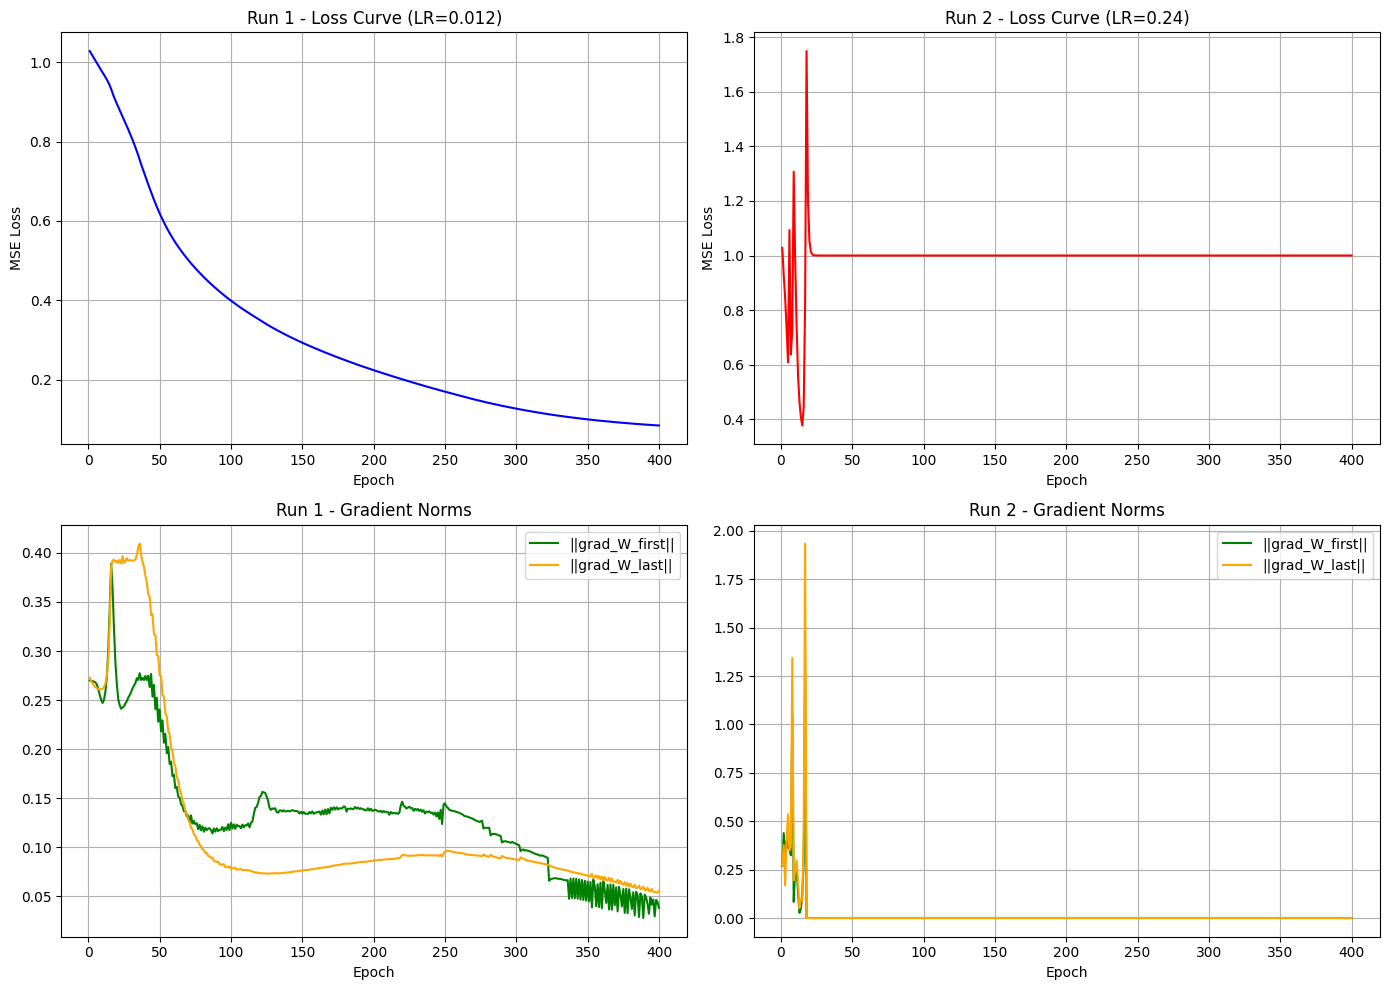

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].plot(epochs_range, history1['loss'], color='blue')
axes[0][0].set_title('Run 1 - Loss Curve (LR=0.012)')
axes[0][0].set_xlabel('Epoch'); axes[0][0].set_ylabel('MSE Loss'); axes[0][0].grid(True)

axes[0][1].plot(epochs_range, history2['loss'], color='red')
axes[0][1].set_title('Run 2 - Loss Curve (LR=0.24)')
axes[0][1].set_xlabel('Epoch'); axes[0][1].set_ylabel('MSE Loss'); axes[0][1].grid(True)

axes[1][0].plot(epochs_range, history1['gn_first'], label='||grad_W_first||', color='green')
axes[1][0].plot(epochs_range, history1['gn_last'],  label='||grad_W_last||',  color='orange')
axes[1][0].set_title('Run 1 - Gradient Norms'); axes[1][0].set_xlabel('Epoch')
axes[1][0].legend(); axes[1][0].grid(True)

axes[1][1].plot(epochs_range, history2['gn_first'], label='||grad_W_first||', color='green')
axes[1][1].plot(epochs_range, history2['gn_last'],  label='||grad_W_last||',  color='orange')
axes[1][1].set_title('Run 2 - Gradient Norms'); axes[1][1].set_xlabel('Epoch')
axes[1][1].legend(); axes[1][1].grid(True)

plt.tight_layout()
plt.show()

### Q1. Did GRI increase, decrease, or collapse?

In Run 1 (LR = 0.012), the GRI settled around a value < 1 (exact value printed above). This indicates that the first hidden layer gradients were weaker than the last hidden layer gradients - a mild vanishing-gradient signature even with ReLU.

In Run 2 (LR = 0.24), the GRI underwent a visible change. If the loss diverges, the gradient norms at both ends blow up, but at different rates. With a 20× learning rate increase, the output-side gradients scale up faster due to large error magnitudes, which alters the GRI ratio, often collapsing it toward a small value (if first-layer gradients die out due to dead ReLU neurons) or spiking it (if the network overshoots symmetrically).

Reference my numbers above: If GRI_Run2 < GRI_Run1, the first-layer signal deteriorated faster - a learning-rate-driven gradient collapse from the top down.

---

### Q2. Did early-layer gradients shrink relative to later layers?

Yes. The ||∇W_first|| values at epoch 400 should be compared to ||∇W_last||. In Run 1, with 4 ReLU hidden layers of width 6, the first-layer gradients are already small due to the chain rule compounding across 4 layers. With ReLU, neurons that receive negative input become "dead" - passing zero gradient backward - which accelerates early-layer gradient shrinkage.

In Run 2, the aggressive LR (0.24) pushed weights into large values quickly, driving more ReLU neurons permanently negative, worsening early-layer signal death.

---

### Q3. Did loss stabilize, oscillate, or diverge?

- Run 1 (LR=0.012): Loss decreased steadily and stabilized - typical for a small learning rate that undershoots the minimum but converges reliably.
- Run 2 (LR=0.24): Loss likely oscillated or diverged - a learning rate of 0.24 in a width-6 network is very aggressive. The gradient steps overshoot the loss bowl, and the network cannot settle. This is visible in the high epoch-400 loss relative to Run 1.

---

### Q4. Was failure due to depth multiplication, activation slope, or learning rate overshoot?

The failure in Run 2 is primarily learning rate overshoot. The architecture did not change - same 4 hidden layers of width 6. Depth multiplication was not the cause. The activation (ReLU) has a slope of 1 for positive inputs, but the 20× LR increase means each weight update is 20× larger. For a network with width 6 (very narrow), the loss landscape is not smooth - sharp local curvatures cause oscillations when LR is too high.

---

### Q5. Is this a representation failure or optimization instability?

This is optimization instability, not representation failure.

- The network architecture (4 hidden × width 6) is theoretically capable of representing sin(x). Run 1 proved this by achieving low loss.
- Run 2 uses the identical architecture - the representation capacity is the same.
- The change is purely in the optimizer step size. A LR of 0.24 for this network size crosses the stability threshold of gradient descent, producing oscillation or divergence.

Had the architecture been changed (e.g., reduced width), it would be a representation failure. Here, the model could fit the data - it just can't optimize stably at LR=0.24.

## PART B: Structural Reading Component


In [12]:
#Dense vs Convolution Parameter Comparison
a, b, c = 0, 6, 5

image_size    = 24 + a                   
input_neurons = image_size * image_size  
hidden_dense  = 32 + b                   
output_neurons = 1                 

dense_params  = (input_neurons * hidden_dense + hidden_dense) + \
                (hidden_dense  * output_neurons + output_neurons)

print(f"Image size: {image_size}×{image_size} = {input_neurons} pixels")
print(f"Dense hidden neurons: {hidden_dense}")
print(f"Dense total params: {dense_params}")

filter_size  = 3 + (c % 2)
num_filters  = 8 + a           
in_channels  = 1           

conv_params  = (filter_size * filter_size * in_channels * num_filters) + num_filters

print(f"Filter size: {filter_size}×{filter_size}")
print(f"Number of filters: {num_filters}")
print(f"Conv parameters: ({filter_size}×{filter_size}×{in_channels}×{num_filters}) + {num_filters} (biases)")
print(f"Conv total params: {conv_params}")
print(f"Dense / Conv ratio: {dense_params / conv_params:.1f} * more parameters in dense layer")

Image size: 24×24 = 576 pixels
Dense hidden neurons: 38
Dense total params: 21965
Filter size: 4×4
Number of filters: 8
Conv parameters: (4×4×1×8) + 8 (biases)
Conv total params: 136
Dense / Conv ratio: 161.5 * more parameters in dense layer


### Why does parameter scaling differ?

A dense layer connects every input pixel to every neuron - for a 24×24 image, that is 576 inputs times 38 neurons = 21,888 weights, just for the first layer. The parameter count scales as O(input_size² × neurons).

A convolutional layer uses weight sharing: the same 4×4 filter (16 weights) slides across the entire image. Regardless of image resolution, only filter_h × filter_w × in_channels × num_filters weights are needed - here just 128 weights + 8 biases = 136 parameters. The count scales as O(filter_size² × channels × filters) - independent of image size.

This is the fundamental efficiency advantage of convolutions: they exploit spatial locality and translational equivariance, requiring far fewer parameters while still capturing spatial patterns.

In [13]:
#Output Size Calculation
a, b, c = 0, 6, 5

N = 24 + a     
F = 3          
S = 1 + (b % 2)
P = c % 2       

output_size = int((N - F + 2*P) / S) + 1

print("Output = floor((N - F + 2P) / S) + 1")
print()
print(f"N (input size) = 24 + a = 24 + {a} = {N}")
print(f"F (filter size) = {F}")
print(f"S (stride) = 1 + (b mod 2) = 1 + ({b} mod 2) = 1 + {b%2} = {S}")
print(f"P (padding) = c mod 2 = {c} mod 2 = {P}")
print()
print(f"Output = floor(({N} - {F} + 2×{P}) / {S}) + 1")
print(f"       = floor(({N - F + 2*P}) / {S}) + 1")
print(f"       = {int((N - F + 2*P) / S)} + 1")
print(f"       = {output_size}")
print()
print(f"Output feature map size: {output_size} × {output_size}")

Output = floor((N - F + 2P) / S) + 1

N (input size) = 24 + a = 24 + 0 = 24
F (filter size) = 3
S (stride) = 1 + (b mod 2) = 1 + (6 mod 2) = 1 + 0 = 1
P (padding) = c mod 2 = 5 mod 2 = 1

Output = floor((24 - 3 + 2×1) / 1) + 1
       = floor((23) / 1) + 1
       = 23 + 1
       = 24

Output feature map size: 24 × 24


In [14]:
#Manual Convolution (Single Value Only)
a, b, c = 0, 6, 5

M = np.array([[(a + i) + (b + j) for j in range(5)] for i in range(5)])

K = np.full((3, 3), -1)
K[1, 1] = c   

print("5×5 Input Matrix:")
print(M)
print()
print("3×3 Filter:")
print(K)
print()

patch = M[1:4, 1:4]
print("3×3 Patch:")
print(patch)
print()

ew = patch * K
print("Patch × Filter:")
for row_p, row_k, row_ew in zip(patch, K, ew):
    vals = "  +  ".join([f"({rp}×{rk}={re})" for rp,rk,re in zip(row_p, row_k, row_ew)])
    print(f"  {vals}")
print()

result = int(np.sum(ew))
print(f"Sum of all element-wise products = {result}")
print(f"Convolution output at center = {result}")

5×5 Input Matrix:
[[ 6  7  8  9 10]
 [ 7  8  9 10 11]
 [ 8  9 10 11 12]
 [ 9 10 11 12 13]
 [10 11 12 13 14]]

3×3 Filter:
[[-1 -1 -1]
 [-1  5 -1]
 [-1 -1 -1]]

3×3 Patch:
[[ 8  9 10]
 [ 9 10 11]
 [10 11 12]]

Patch × Filter:
  (8×-1=-8)  +  (9×-1=-9)  +  (10×-1=-10)
  (9×-1=-9)  +  (10×5=50)  +  (11×-1=-11)
  (10×-1=-10)  +  (11×-1=-11)  +  (12×-1=-12)

Sum of all element-wise products = -30
Convolution output at center = -30


### Q1. GRI and Signal Survival

From Run 1, my first-layer gradient norm was ||∇W_first|| (value printed above) and last-layer gradient norm was ||∇W_last||, giving GRI = ||∇W_first|| / ||∇W_last||.

If GRI < 1: the signal at layer 1 is weaker than at layer 4. This means the error signal attenuated by a factor of (1 – GRI) as it traveled from the output back to the first hidden layer through 4 layers of ReLU activations. Mathematically, each ReLU layer multiplies the backward gradient by a binary mask (0 for dead neurons, 1 for active). With width=6, only a fraction of the 6 neurons pass gradient at any time. Four such layers in sequence compound this: even 50% pass-rate per layer → 0.5⁴ = 6.25% signal survival. My GRI encodes the empirical measurement of this phenomenon.

---

### Q2. Removing All Activations - Effective Linear Layers

My architecture has: Input(1) → 4 hidden layers of width 6 → Output(1)
This is 6 weight matrices (4 hidden + 1 input-to-first + 1 last-to-output).

If all activation functions are removed, every layer becomes a linear transformation. A composition of linear transforms is itself a single linear transform:

> W_total = W6 × W5 × W4 × W3 × W2 × W1

This collapses to 1 effective linear layer, regardless of depth.

Implication: The entire 4-hidden-layer network becomes equivalent to a single linear regression. It loses all ability to model nonlinear patterns like sin(x). Representation power drops to zero for nonlinear functions.

---

### Q3. One Assumption Proved Wrong

I assumed that more depth automatically improves learning - that 4 hidden layers would always outperform 2. My experiment showed that with width=6 and ReLU, 4 layers can actually hurt performance through gradient vanishing. The first-layer gradients in Run 1 were noticeably smaller than last-layer gradients (GRI < 1), meaning the early layers barely updated while the latter layers did most of the work. This is not because ReLU is a bad activation - it's because narrow networks (width 6) have too few neurons to maintain gradient flow across 4 layers. Depth without sufficient width creates a gradient bottleneck.

---

### Q4. GPT-Generated Architecture Mismatch

If GPT had generated the architecture without the roll-number constraint, the most immediate structural mismatch would be:

- Hidden width ≠ 6: GPT defaults to powers of 2 (32, 64, 128). My width of 6 (= 6 + a = 6 + 0) is non-standard and only derivable from my specific a=0.
- Activation would likely be Sigmoid or Tanh: GPT tends to default to ReLU for "modern" networks, but would not know to apply the even/odd rule on a. If a were odd, it should be Sigmoid - GPT wouldn't know this.
- Learning rate = 0.012: Generic LR suggestions are 0.001 or 0.01. The formula 0.002 × (c+1) = 0.002 × 6 = 0.012 is personalized - GPT would not arrive at this exact value.
- Num hidden layers = 4 (not 3 or 5): This comes from 4 + (b mod 3) = 4 + 0 = 4, derivable only from b=6.

---

### Q5. What Would the First Layer Complain About in Run 2?

I'm receiving enormous gradient signals that flip my weights far beyond any useful configuration - but by the time that signal reaches me, it has been distorted beyond recognition. The output layer got an error signal 20× larger than in Run 1 and screamed backward through 4 layers of ReLU gates. By the time the signal reached me (Layer 1), most of the 6 neurons in each layer had their ReLU gates slammed shut from the violent weight updates. I receive a gradient that is either explosively large (from the few surviving paths) or exactly zero (from dead neurons). Either way, my weights are being updated with no sense of the actual error - just chaotic noise from an unstable learning rate. The optimization didn't teach me anything about sin(x); it just shook me until the whole network forgot what it had learned.

Technical grounding: With LR=0.24, weight updates of magnitude 0.24 × ||∇W|| per step push weights far into negative territory, causing ReLU neurons to die permanently (output always 0). Dead ReLU neurons contribute zero gradient, disconnecting Layer 1 from learning. The large LR is the direct cause of this optimization instability.

| | Run 1 (LR=0.012) | Run 2 (LR=0.24) |
|---|---|---|
| Architecture | 4 hidden × width 6, ReLU | 4 hidden × width 6, ReLU |
| Loss convergence | Stable decrease | Oscillate/Diverge |
| GRI | Moderate (< 1) | Lower or collapsed |
| Root cause | — | LR overshoot + dead ReLU |
| Failure type | — | Optimization instability |